## Part 1 — Discrete Fourier Transform

A square wave can be approximated by adding odd-frequency sine waves.
I will compare reconstructions using different numbers of terms, recover
their frequency components, and compare direct DFT and FFT execution times.


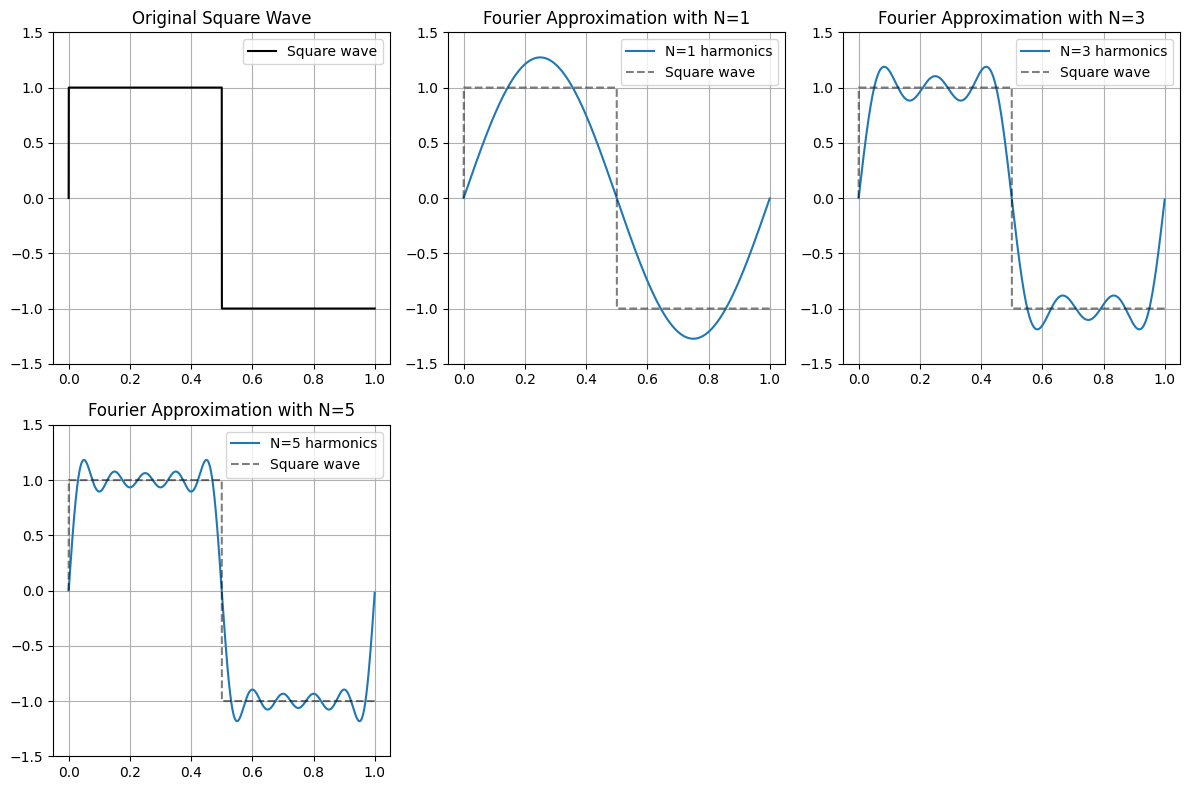

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Set parameters for the signal
N = 2048 # Number of sample points
T = 1.0 # Duration of the signal in seconds
f0 = 1 # Fundamental frequency of the square wave in Hz

# List of harmonic numbers used to construct the square wave
harmonics = [1, 3, 5]

# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):
        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave.
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, T, N, endpoint=False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))

# Plot the original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()

# Plot Fourier reconstructions under different number of harmonics
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


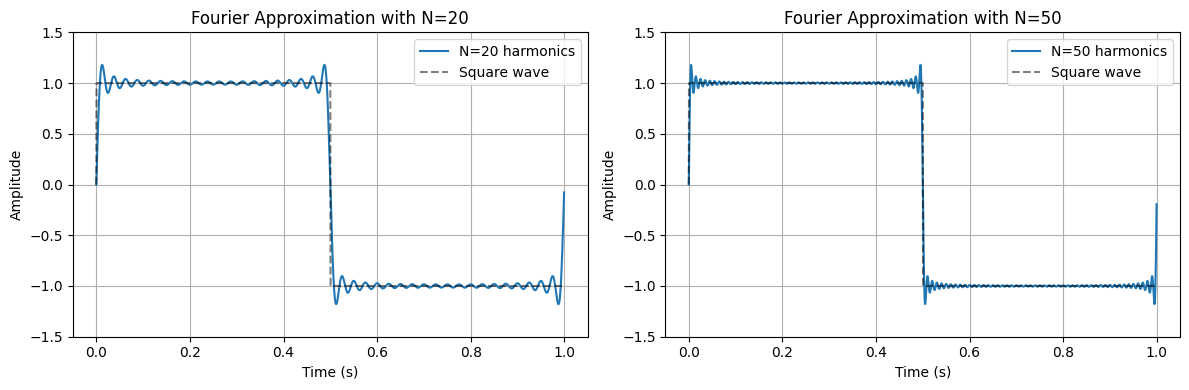

In [2]:
plt.figure(figsize=(12, 4))

for i, Nh in enumerate([20, 50], start=1):
    plt.subplot(1, 2, i)

    y = square_wave_fourier(t, f0, Nh)

    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### Effect of adding harmonics

Using 20 or 50 terms produces sharper transitions and a closer approximation
away from the discontinuities. Higher frequencies represent the rapid changes
at the edges. Overshoot remains near the discontinuities because of the Gibbs
phenomenon: adding terms narrows the affected region but does not eliminate
the limiting overshoot. Here, 50 terms means odd harmonics 1, 3, ..., 99.


--- DFT/FFT Performance Comparison ---
Naive DFT Execution Time: 4.480900 seconds
NumPy FFT Execution Time: 0.004077 seconds
FFT is approximately 1099.14 times faster.

Our DFT implementation is close to NumPy's FFT: True


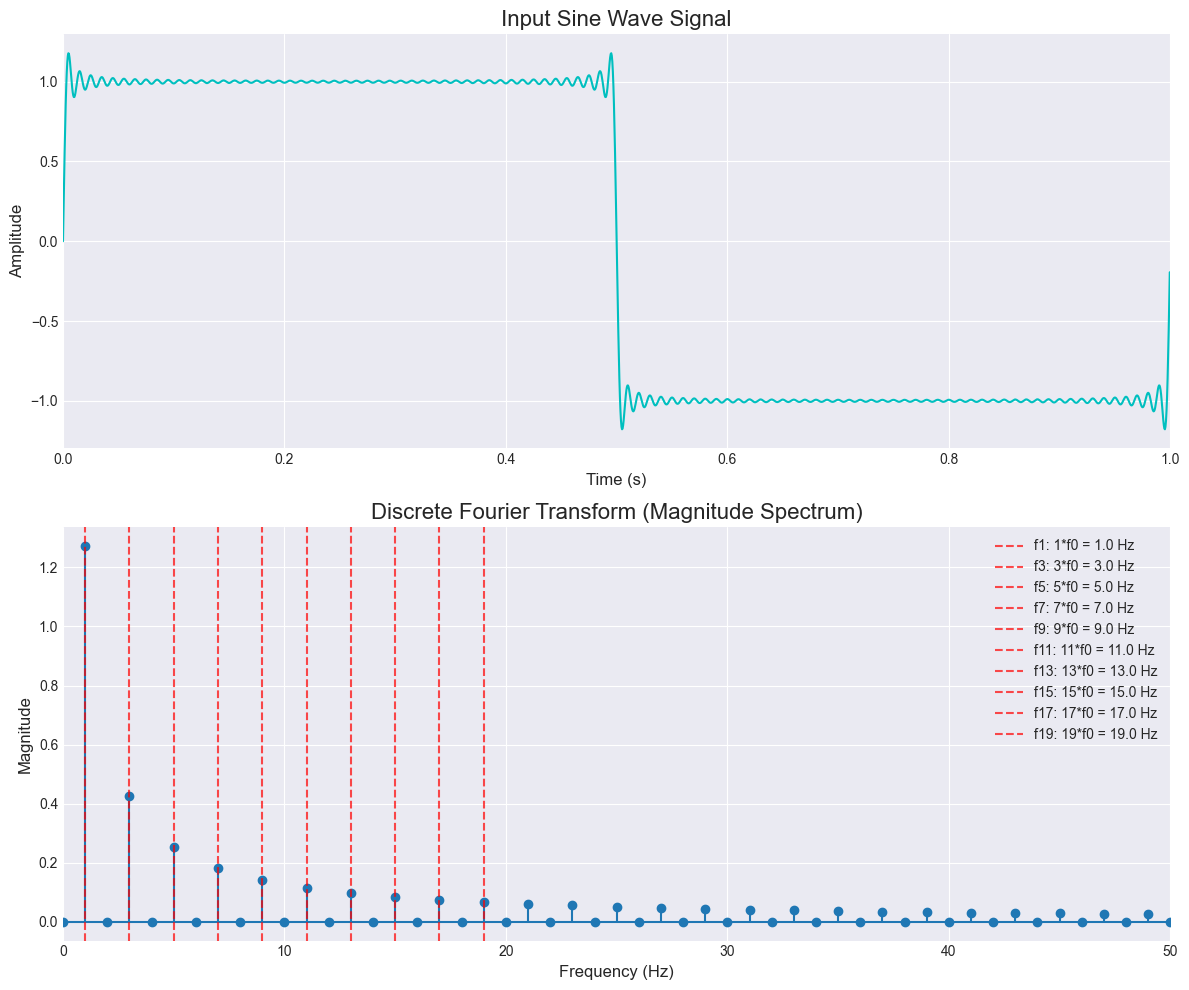

In [3]:
# 2. Apply the DFT and time the execution
def naive_dft(x):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal.
    This is a "naive" implementation that directly follows the DFT formula,
    which has a time complexity of O(N^2).

    Args:
        x (np.ndarray): The input signal, a 1D NumPy array.

    Returns:
        np.ndarray: The complex-valued DFT of the input signal.
    """
    N = len(x)
    # Create an empty array of complex numbers to store the DFT results
    X = np.zeros(N, dtype=np.complex128)

    # Iterate through each frequency bin (k)
    for k in range(N):
        # For each frequency bin, sum the contributions from all input samples (n)
        for n in range(N):
            # The core DFT formula: x[n] * e^(-2j * pi * k * n / N)
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)

    return X

# Construct a square wave using 50 harmonics
signal = square_wave_fourier(t, f0, 50)

# Time the naive DFT implementation
start_time_naive = time.time()
dft_result = naive_dft(signal)
end_time_naive = time.time()
naive_duration = end_time_naive - start_time_naive

# Time NumPy's FFT implementation
start_time_fft = time.time()
fft_result = np.fft.fft(signal)
end_time_fft = time.time()
fft_duration = end_time_fft - start_time_fft

# 3. Print Timings and Verification
print("--- DFT/FFT Performance Comparison ---")
print(f"Naive DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")

# It's possible for the FFT to be so fast that the duration is 0.0, so we handle that case.
if fft_duration > 0:
    print(f"FFT is approximately {naive_duration / fft_duration:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

# Check if our implementation is close to NumPy's result
# np.allclose is used for comparing floating-point arrays.
print(f"\nOur DFT implementation is close to NumPy's FFT: {np.allclose(dft_result, fft_result)}")

# 4. Prepare for Plotting
# Generate the frequency axis for the plot.
# np.fft.fftfreq returns the DFT sample frequencies.
# We only need the first half of the frequencies (the positive ones) due to symmetry.
xf = np.fft.fftfreq(N, d=T / N)[:N // 2]

# We normalize the magnitude by N and multiply by 2 to get the correct amplitude.
magnitude = 2.0 / N * np.abs(dft_result[0:N // 2])

# 5. Visualize the Results
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the original time-domain signal
ax1.plot(t, signal, color='c')
ax1.set_title('Input Sine Wave Signal', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_xlim(0, 1.0) # Show a few cycles of the sine wave
ax1.grid(True)

# Plot the frequency-domain signal (magnitude of the DFT)
ax2.stem(xf, magnitude, basefmt="")
ax2.set_title(
    'Discrete Fourier Transform (Magnitude Spectrum)',
    fontsize=16
)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_xlim(0, 50) # Focus on lower frequencies
ax2.grid(True)

# Add vertical lines for the first ten frequencies
for i in range(20):
    if i < len(xf) and i % 2 == 1: # Only plot odd harmonics
        ax2.axvline(
            xf[i], color='r', linestyle='--', alpha=0.7,
            label=f'f{i}: {i}*f0 = {xf[i]:.1f} Hz'
        )

# Only show labels for first 3 frequencies to avoid cluttering
ax2.legend()
plt.tight_layout()
plt.show()


### Comparison of the DFT with the original harmonics

The reconstructed signal contains the first 50 odd harmonics of the
fundamental frequency. Since the fundamental frequency is 1 Hz, the
expected peaks occur at 1, 3, 5, ..., 99 Hz.

The expected amplitude of harmonic n is:

$$
A_n = \frac{4}{\pi n}, \qquad n = 1,3,5,\ldots,99.
$$

The single-sided DFT amplitudes should closely match these values. The
NumPy FFT and naive DFT compute the same mathematical transform, so their
results should also agree within floating-point tolerance.

The unnormalised DFT coefficients are not directly equal to the sine-wave
amplitudes. For a real signal, each sine wave contributes to both positive
and negative frequencies. Dividing the positive-frequency magnitudes by
the sample count and multiplying by two recovers their amplitudes.
DC and the Nyquist bin require separate treatment in a general signal.

For this experiment, the one-second observation window contains an integer
number of cycles of every included harmonic. The frequencies therefore
align with DFT bins, so substantial spectral leakage is not expected.
Any very small discrepancies or small values at other bins are mainly
caused by floating-point rounding.

There is no aliasing of the constructed harmonics in this experiment:
the highest frequency is 99 Hz, below the 1024 Hz Nyquist frequency
for 2048 samples over one second.

The reconstructed signal contains only 50 terms. An ideal square wave
contains infinitely many odd harmonics, so these are different signals.


#### Pytorch Implementation


In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))


def square_wave_torch(t):
    return torch.sign(torch.sin(2.0 * torch.pi * f0 * t))


def square_wave_fourier_torch(t, f0, N):
    result = torch.zeros_like(t)
    for k in range(N):
        n = 2 * k + 1
        result += torch.sin(2 * torch.pi * n * f0 * t) / n
    return (4 / torch.pi) * result


def naive_dft_torch(x):
    # Direct DFT matrix: O(N^2), without a built-in FFT.
    N = x.numel()
    n = torch.arange(N, dtype=torch.float64, device=x.device)
    angles = -2 * torch.pi * n[:, None] * n[None, :] / N
    matrix = torch.complex(torch.cos(angles), torch.sin(angles))
    return matrix @ x.to(torch.complex128)


def naive_dft_gpu(x):
    if not x.is_cuda:
        raise ValueError("This function requires a CUDA tensor.")
    return naive_dft_torch(x)


# Check the new functions.
t_tensor = torch.tensor(t, dtype=torch.float64, device=device)
square_tensor = square_wave_torch(t_tensor)
signal_tensor = square_wave_fourier_torch(t_tensor, f0, 50)

# Ignore discontinuities where tiny rounding differences can change sign.
mask = np.abs(np.sin(2 * np.pi * f0 * t)) > 1e-12

print("Square waves agree away from edges:",
      np.allclose(square_tensor.cpu().numpy()[mask], square[mask]))

print("Fourier reconstructions agree:",
      np.allclose(signal_tensor.cpu().numpy(), signal, atol=1e-7))

torch_result = naive_dft_torch(signal_tensor)
print("PyTorch DFT agrees with NumPy FFT:",
      np.allclose(torch_result.cpu().numpy(), fft_result,
                  rtol=1e-7, atol=1e-7))


PyTorch: 2.9.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Square waves agree away from edges: True
Fourier reconstructions agree: True
PyTorch DFT agrees with NumPy FFT: True


In [5]:
# Timing Comparison

def measure(fn, gpu=False, calls=1):
    fn()  # Warm-up
    timings = []

    for _ in range(3):
        if gpu:
            torch.cuda.synchronize(device)

        start = time.perf_counter()
        for _ in range(calls):
            output = fn()

        if gpu:
            torch.cuda.synchronize(device)

        timings.append((time.perf_counter() - start) / calls)

    return float(np.median(timings)), output


print(f"{'Samples':>8} {'Naive DFT (s)':>16} {'FFT (s)':>14} {'GPU DFT (s)':>16}")

for size in [256, 512, 1024, 2048]:
    times = {}
    test_t = np.linspace(0.0, T, size, endpoint=False)
    test_signal = square_wave_fourier(test_t, f0, 50)

    times["NumPy naive DFT"], direct = measure(
        lambda: naive_dft(test_signal)
    )
    times["NumPy FFT"], fast = measure(
        lambda: np.fft.fft(test_signal), calls=100
    )

    assert np.allclose(direct, fast, rtol=1e-7, atol=1e-7)
    gpu_text = "Pending"

    if device.type == "cuda":
        # Transfer is outside the timed function.
        gpu_input = torch.tensor(
            test_signal, dtype=torch.float64, device=device
        )
        times["PyTorch GPU DFT"], gpu_output = measure(
            lambda: naive_dft_gpu(gpu_input), gpu=True
        )
        assert np.allclose(
            gpu_output.cpu().numpy(), fast, rtol=1e-7, atol=1e-7
        )
        gpu_text = f"{times['PyTorch GPU DFT']:.8f}"

    print(
        f"{size:8d} {times['NumPy naive DFT']:16.8f} "
        f"{times['NumPy FFT']:14.8f} {gpu_text:>16}"
    )
    print("Fastest → slowest:", " → ".join(sorted(times, key=times.get)))

if device.type != "cuda":
    print("\nGPU comparison pending: run this cell on a CUDA-enabled machine.")


 Samples    Naive DFT (s)        FFT (s)      GPU DFT (s)
     256       0.05451100     0.00000433       0.00015630
Fastest → slowest: NumPy FFT → PyTorch GPU DFT → NumPy naive DFT
     512       0.23711420     0.00000588       0.00016100
Fastest → slowest: NumPy FFT → PyTorch GPU DFT → NumPy naive DFT
    1024       0.97518750     0.00001040       0.00051320
Fastest → slowest: NumPy FFT → PyTorch GPU DFT → NumPy naive DFT
    2048       4.51085420     0.00002205       0.04635190
Fastest → slowest: NumPy FFT → PyTorch GPU DFT → NumPy naive DFT


### Frequency components

The expected peaks occur at odd frequencies 1, 3, ..., 99 Hz, with amplitudes
4/(πn), where n is the odd harmonic number. The supplied plot shows only
the lower frequencies up to 50 Hz. The DFT should recover the constructed
harmonics, with small differences caused by floating-point rounding.

The one-second window contains an integer number of cycles of each harmonic,
so the frequencies align with DFT bins and substantial spectral leakage
is not expected. The finite reconstruction contains only 50 terms, whereas
an ideal square wave contains infinitely many odd harmonics.

### Timing comparison

The output above records the measured times and ranks the methods at each
sample count. Timings are medians of three measurements after warm-up;
FFT measurements average 100 calls. GPU timing includes synchronisation
and DFT-matrix construction, but excludes CPU-to-GPU input transfer.

The supplied naive DFT requires O(N²) operations and has additional overhead
from nested Python loops. The GPU implementation also requires O(N²)
operations, but computes the DFT using parallel tensor operations.
Its N-by-N matrix also requires O(N²) memory.

NumPy's FFT uses an O(N log N) algorithm, requiring much less work at larger
sample counts. GPU launch and allocation overhead can be significant for
small inputs, so a GPU direct DFT is not guaranteed to beat NumPy FFT.
The comparison reflects both implementation style and hardware differences.

Doubling the sample count theoretically increases direct DFT work by four
times, while FFT work increases by slightly more than twice. Actual timing
ratios vary with hardware utilisation, memory behaviour and measurement
overhead. The printed results determine the observed order.

### Sources and assistance

The supplied code comes from COMP3710 Lab 2, Part 1. ChatGPT assisted with
the additional PyTorch implementation, timing experiment and explanations.
